<a href="https://colab.research.google.com/github/Foll0wTh3Wh1teRabbit/ML/blob/master/PCA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Метод главных компонент (англ. principal component analysis, PCA) — один из основных способов уменьшить размерность данных, потеряв наименьшее количество информации. Изобретён Карлом Пирсоном в 1901 году. Применяется во многих областях, в том числе в эконометрике, биоинформатике, обработке изображений, для сжатия данных, в общественных науках.

Вычисление главных компонент может быть сведено к вычислению сингулярного разложения матрицы данных или к вычислению собственных векторов и собственных значений ковариационной матрицы исходных данных. Иногда метод главных компонент называют преобразованием Кархунена — Лоэва или преобразованием Хотеллинга.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.inspection import DecisionBoundaryDisplay
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.decomposition import PCA

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score, precision_score, recall_score, mean_absolute_error, mean_squared_error
from sklearn import tree

Обучим RandomForest на первых двух признаках датасета Iris

In [ ]:
iris = load_iris()

df = pd.DataFrame(iris.data, columns = iris.feature_names)
df["target"] = iris.target

df

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2
146,6.3,2.5,5.0,1.9,2
147,6.5,3.0,5.2,2.0,2
148,6.2,3.4,5.4,2.3,2


In [ ]:
X, y = load_iris(return_X_y = True)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.20)

fn=iris.feature_names
cn=iris.target_names

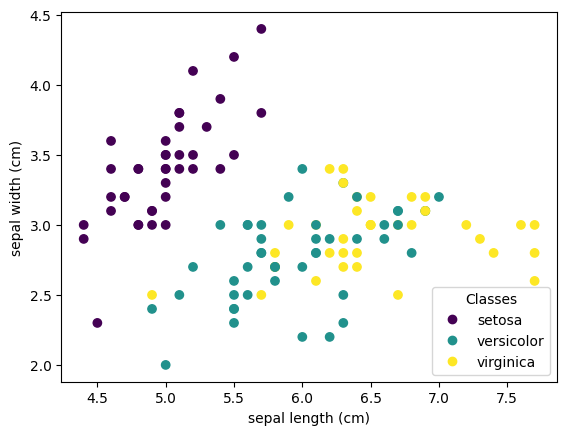

In [ ]:
_, ax = plt.subplots()
scatter = ax.scatter(X_train[:, 0], X_train[:, 1], c=y_train)

ax.set(xlabel=iris.feature_names[0], ylabel=iris.feature_names[1])

_ = ax.legend(scatter.legend_elements()[0], iris.target_names, loc="lower right", title="Classes")

In [ ]:
rfc = RandomForestClassifier().fit(X_train[:, :2], y_train)

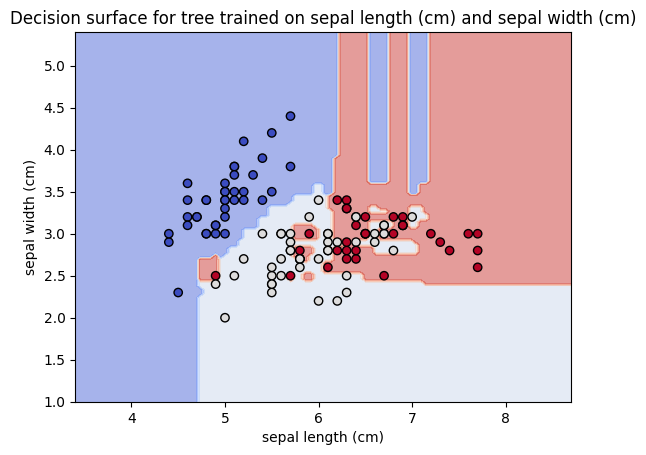

In [ ]:
disp = DecisionBoundaryDisplay.from_estimator(
    rfc,
    X_train[:, :2],
    response_method="predict",
    xlabel=iris.feature_names[0], ylabel=iris.feature_names[1],
    alpha=0.5,
    cmap=plt.cm.coolwarm
)

# Plotting the data points
disp.ax_.scatter(X_train[:, 0], X_train[:, 1],
                 c=y_train, edgecolor="k",
                 cmap=plt.cm.coolwarm)

plt.title(f"Decision surface for tree trained on {iris.feature_names[0]} and {iris.feature_names[1]}")
plt.show()

In [ ]:
y_pred = rfc.predict(X_test[:, :2])

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, average='macro'))
print("Recall:", recall_score(y_test, y_pred, average='macro'))

Accuracy: 0.7333333333333333
Precision: 0.7259259259259259
Recall: 0.735042735042735


Применим PCA с целью снижения размерности до 2-ух

In [ ]:
pca = PCA(n_components=2)

pca.fit(X_train)
X_train = pca.transform(X_train)

pca.fit(X_test)
X_test = pca.transform(X_test)

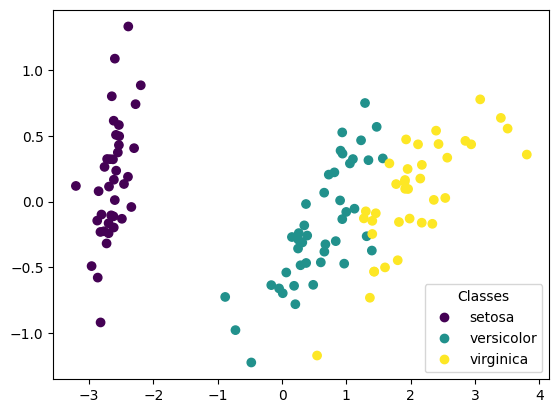

In [ ]:
_, ax = plt.subplots()
scatter = ax.scatter(X_train[:, 0], X_train[:, 1], c=y_train)

_ = ax.legend(scatter.legend_elements()[0], iris.target_names, loc="lower right", title="Classes")

Обучим RandomForest для классификации тех же объектов в гиперпространстве меньшей размерности

In [ ]:
rfc_new = RandomForestClassifier().fit(X_train, y_train)

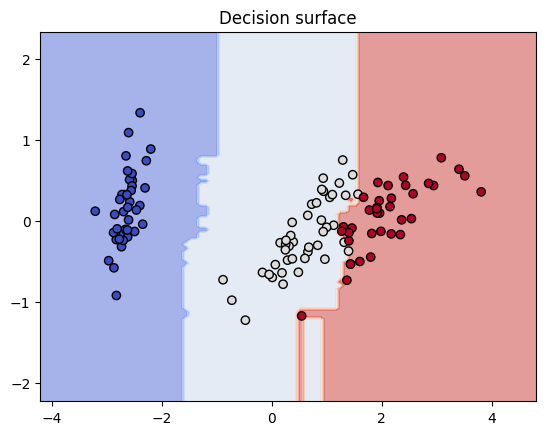

In [ ]:
disp = DecisionBoundaryDisplay.from_estimator(
    rfc_new,
    X_train,
    response_method="predict",
    alpha=0.5,
    cmap=plt.cm.coolwarm
)

# Plotting the data points
disp.ax_.scatter(X_train[:, 0], X_train[:, 1],
                 c=y_train, edgecolor="k",
                 cmap=plt.cm.coolwarm)

plt.title(f"Decision surface")
plt.show()

In [ ]:
y_pred = rfc_new.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, average='macro'))
print("Recall:", recall_score(y_test, y_pred, average='macro'))

Accuracy: 0.9
Precision: 0.8888888888888888
Recall: 0.923076923076923
